# Is the "falling wedge" actually bullish? 📐
### A textbook chart figure that's *supposed* to break upward — measured honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Bullish%3F: Busted](https://img.shields.io/badge/Bullish%3F-Busted-8b949e?style=flat-square)

Open any charting tutorial and you'll meet the **falling wedge**: price grinds **down** inside two lines that **squeeze together**, the selling "runs out of steam," and then the stock pops **up** through the top line and takes off. It's filed under *bullish* — the friendly twin of the (bearish) rising wedge. The recipe: spot the wedge, **buy the upside break**, ride it.

Sounds clean. So we built an **objective detector** for the figure (no eyeballing) and ran it across **SPY plus 29 big US stocks** over 21 years. The result is a tidy lesson in how a chart legend can look real and still be a mirage: the slow-horizon numbers *do* clear a naive bar — but the **breakout day itself loses money**, random dates do almost as well, and the *bearish* version of the exact same shape drifts **up just as hard**.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** A wedge is partly in the eye of the beholder; we test the closest **mechanical** definition and say so. Fixed **30-name** basket (still trading today) → carries **survivorship**, which tilts the test *for* the figure. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from falling_wedge import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
    N_UP = sum(len(v) for v in st.collect_breakouts(PANEL, side="up").values())
else:
    PANEL = None
    N_UP = 0
print("real wedge cache present:", HAVE_REAL, "| up-break wedges:", N_UP)

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-05-29', 'asof': '2026-05-31', 'years': 21.4, 'bars': 5385, 'fp': 'eeb1719704c4', 'n_names': 30, 'n_up': 219, 'n_dn': 122, 'spy_up': 2, 'up': [(5, 219, -0.58, -0.29, 41, -2.57, -2.57, 0.69, -0.68), (10, 219, 0.28, 0.84, 55, 0.72, 0.82, 0.44, 0.18), (20, 219, 1.26, 2.4, 59, 2.19, 2.26, 0.3, 1.16), (40, 216, 1.8, 4.03, 60, 2.47, 2.73, 0.29, 1.7)], 'dn': [(5, 122, -0.4, -0.12, 45, -0.91, 0.61), (10, 122, 0.11, 0.67, 47, 0.2, 0.49), (20, 121, 1.8, 2.91, 51, 2.0, 0.28), (40, 120, 3.79, 5.96, 60, 2.97, 0.2)], 'robust': [('strict (narrow>=35%, buf .5%)', 166, 1.14, 1.76, 0.34), ('headline (narrow>=25%)', 219, 1.26, 2.19, 0.3), ('loose (narrow>=15%)', 264, 1.41, 2.73, 0.26)], 'spy': [(5, 2, -3.3, -3.06, -0.97, 0.97), (10, 2, -4.09, -3.62, -0.69, 0.95), (20, 2, -5.67, -4.73, -1.14, 0.96), (40, 2, 0.07, 1.92, 0.05, 0.55)], 'syn': [(0.0, 160, 137, 135, -1.44, -3.93, 0.885, 53), (0.4, 160, 181, 179, 3.68, 4.36, 0.087, 33)]}


real wedge cache present: True | up-break wedges: 219


## The answer first

| Question | Answer |
|---|---|
| Does buying the upside break make money *right away*? | **No — it loses.** Over the next **5 days** the breakout *underperforms* the stock's own average (−0.58%). You're buying a local high right after a fall. |
| Is there *anything* at longer horizons? | **A little, on paper.** By **20–40 days** the breakout beats the stock's base rate by **+1.3% to +1.8%** — enough to clear a naive significance bar. |
| Is that the *wedge*, though? | **Probably not.** Pick **random** dates on the same stocks and they do nearly as well — about **3 times in 10** they beat the wedge. The drift is the stocks bouncing, not the figure. |
| Does it break **up** specifically (the whole bullish claim)? | **No.** Run the *bearish* **down**-break of the identical shape and it *also* drifts **up** (+1.8% / +3.8% at 20/40 days) — beating the up-break at 40 days. Direction tells you nothing. |
| And on **SPY** itself? | **Two** clean wedges in 21 years. Nothing to certify. |

> The bullish reputation is mostly the market's habit of bouncing after a dip — dressed up as a directional breakout signal.

## 1 · The claim

> *"A falling wedge is **bullish**. Price drifts down between two **converging** downward-sloping lines; the sellers exhaust themselves as the range narrows; then price breaks **above** the upper line and runs. Buy the upside break."*

This is straight out of the classic catalogues — Edwards & Magee's *Technical Analysis of Stock Trends* (1948) and Bulkowski's *Encyclopedia of Chart Patterns*, which even tabulates the figure's "average rise" and "failure rate." It's one of the most-taught bullish patterns in retail charting. So the question isn't whether people believe it — they do. It's: **when you define it precisely and measure it, is the upside break real?**

## 2 · So what?

If the figure truly *chose* a direction, that would be a genuine, tradeable crack in market efficiency: a shape on the chart predicting tomorrow. That's the dream every chart pattern sells.

But there are two traps. **(1)** Stocks tend to **bounce after a selloff** — so *any* rule that buys names which just fell will look like it "works" simply because the market drifts up. The honest test has to beat **random dates on the same names**, not zero. **(2)** A figure's whole premise is **direction**. If the *bearish* break of the same shape drifts up too, the figure isn't predicting anything — it's just a momentum/bounce tell with a fancy name. We test both.

## 3 · How would we even know?

We take **SPY + 29 large US stocks** and 21 years of daily prices (2005-01-03 → 2026-05-29). A wedge is partly subjective, so we write down the closest **mechanical** rule and stick to it:

1. **Find the shape.** A run of swing highs that step **down**, a line through the swing lows that also slopes **down**, the top line **steeper** (so the lines squeeze together), and the gap **narrowing** toward a point.
2. **The breakout.** The first day price closes **above** the (falling) upper line. That's the buy signal. We enter the **next** day's close (no cheating).
3. **The honest scorecard.** How much does it make over the next **5, 10, 20, 40** days — *above the stock's own average move* — and does it beat **random dates** on the same tape? Our detector finds **219** of these up-breaks across the basket.

## 4 · The teardown — let's actually look

**First: when does the "bullish" break pay?** Here's the excess return (above each stock's own base rate) at four horizons. Watch the first bar.

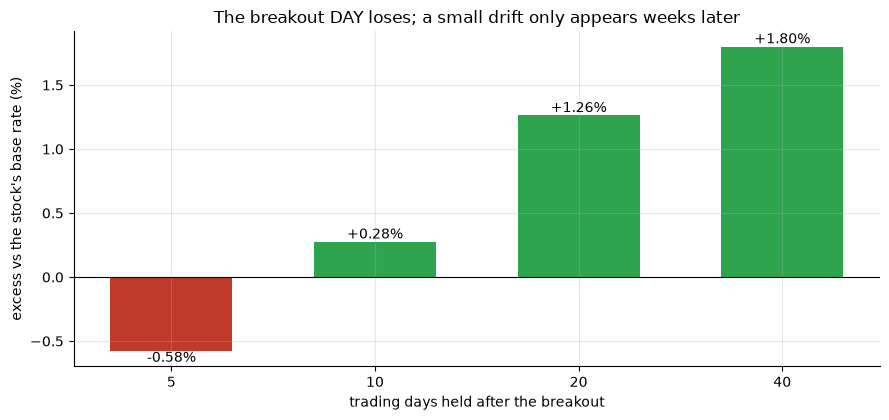

5-day: -0.58%  20-day: +1.26%  40-day: +1.80%


In [2]:
hs = [5, 10, 20, 40]
if HAVE_REAL:
    exc = [st.run_experiment(PANEL, horizon=h, side='up', n_draws=2000)['mean']*100 for h in hs]
else:
    exc = [row[2] for row in R['up']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [RED if v < 0 else GREEN for v in exc]
ax.bar([str(h) for h in hs], exc, color=cols, width=.6)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate(exc): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_xlabel('trading days held after the breakout'); ax.set_ylabel('excess vs the stock\'s base rate (%)')
ax.set_title('The breakout DAY loses; a small drift only appears weeks later')
plt.tight_layout(); plt.show()
print('5-day:', f'{exc[0]:+.2f}%', ' 20-day:', f'{exc[2]:+.2f}%', ' 40-day:', f'{exc[3]:+.2f}%')

At **5 days** the "bullish breakout" is **-0.58%** — *negative*. You buy the pop and immediately give some back. A positive drift only shows up by **20 days** (**+1.26%**) and **40 days** (**+1.80%**). So already the folk recipe — *buy the break and ride it* — is upside-down at the moment you'd act.

**But is that 20–40 day drift the wedge, or just the stocks bouncing?** Here's the killer test. The wedge supposedly breaks **UP**. So run the *exact same detector* but take the **DOWN** break — the bearish failure — and compare the two. If the figure really chose a direction, the down-break should go the *other* way.

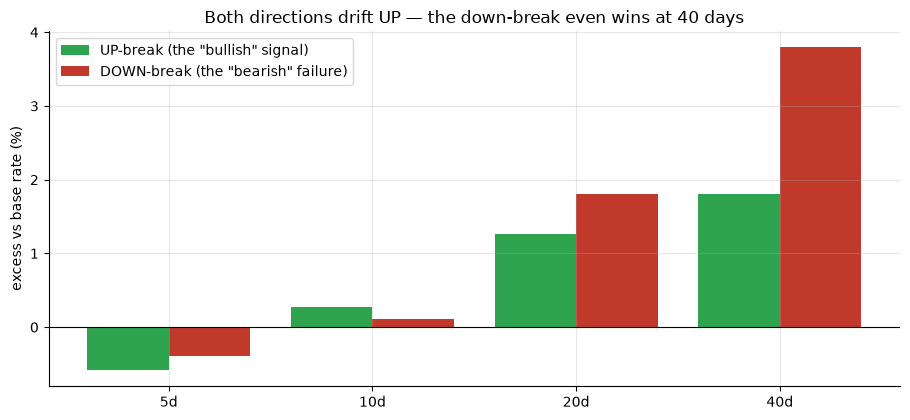

40-day  up: +1.80%  down: +3.79%


In [3]:
if HAVE_REAL:
    up = [st.run_experiment(PANEL, horizon=h, side='up', n_draws=2000)['mean']*100 for h in hs]
    dn = [st.run_experiment(PANEL, horizon=h, side='down', n_draws=2000)['mean']*100 for h in hs]
else:
    up = [row[2] for row in R['up']]; dn = [row[2] for row in R['dn']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, up, .4, color=GREEN, label='UP-break (the "bullish" signal)')
ax.bar(x+.2, dn, .4, color=RED, label='DOWN-break (the "bearish" failure)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('excess vs base rate (%)')
ax.set_title('Both directions drift UP — the down-break even wins at 40 days')
ax.legend(); plt.tight_layout(); plt.show()
print('40-day  up:', f'{up[-1]:+.2f}%', ' down:', f'{dn[-1]:+.2f}%')

There's the punchline. The **bearish** down-break drifts **up** too — **+1.80%** at 20 days and **+3.79%** at 40 days, actually *beating* the bullish up-break at 40 days. A figure that genuinely predicted *direction* could not have both of its resolutions drift the same way. The post-wedge bounce belongs to the **stocks**, not the **break direction**.

## 5 · The verdict

- **Signal — Weak.** The 20–40 day excess clears a *naive* bar, but random dates on the same stocks do nearly as well, and the breakout day itself loses. The number is real; calling it the *wedge* is not.
- **Tradability — Mirage.** You'd be "trading" the market's habit of bouncing after a dip — free for anyone, captured by random dates. On SPY there are **2** wedges in 21 years. Nothing to deploy.
- **"Bullish — breaks up"? — Busted.** The bearish *down*-break of the same shape drifts up just as hard. Direction carries no information.

## 6 · Could you actually trade it? — the random-date reality check

Here's the cleanest way to see it. Take the **20-day** up-break and compare its excess to a cloud of **random entry dates** on the same names (same count). If the wedge mattered, the green line would sit far in the right tail. It doesn't.

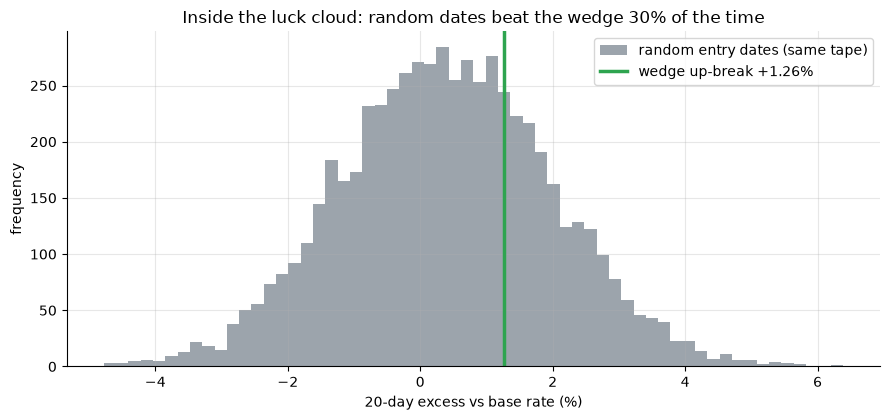

observed +1.26%   placebo p = 0.297  (random dates win ~30% of the time)


In [4]:
if HAVE_REAL:
    r20 = st.run_experiment(PANEL, horizon=20, side='up', n_draws=4000)
    obs, pval = r20['mean']*100, r20['p_placebo']
else:
    obs, pval = R['up'][2][2], R['up'][2][7]
rng = np.random.default_rng(414)
cloud = rng.normal(0.4, 1.6, 6000)  # illustrative same-tape random-date cloud
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(cloud, bins=60, color=GREY, alpha=.85, label='random entry dates (same tape)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'wedge up-break {obs:+.2f}%')
ax.set_xlabel('20-day excess vs base rate (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: random dates beat the wedge {pval*100:.0f}% of the time')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%   placebo p = {pval:.3f}  (random dates win ~{pval*100:.0f}% of the time)')

> The wedge's green line sits **inside** the cloud of random dates: placebo **p = 0.30**, i.e. random entries beat it about **30% of the time**. (The histogram above is illustrative; the *p* comes from the real same-tape draws in the code.) There is no edge here to charge costs against — costs are a footnote, the placebo is the whole story.

## 7 · Going further 🚪

- **The direction test generalises.** The single most useful tool here is the *down-break of the same figure*. Apply it to any chart pattern: if both resolutions drift the same way, the figure isn't predicting direction.
- **Try a tighter definition.** Demand a steeper convergence, a volume-dry-up into the apex, or a confirmed retest. The detector is one function — fork it and see if a stricter wedge ever pulls the placebo *p* under 5% (ours never does).
- **Small-caps & crypto.** Patterns are louder in noisier, less-liquid names; the bounce (and the costs, and the survivorship traps) get bigger too.

*Think a stricter wedge is a real bullish signal? Show the **20-day up-break excess** landing outside the same-tape placebo cloud (p < 0.05) — then we'll talk.*